# 2_classification_modeling
Train a Softmax (Multinomial) Logistic Regression model, perform CV and hyperparameter tuning, evaluate with confusion matrix and classification report.

In [7]:
%%bash
pip install -q scikit-learn pandas matplotlib seaborn joblib


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import os

In [6]:
# Load dataset
dataset = load_dataset('hpe-ai/medical-cases-classification-tutorial')
train_df = pd.DataFrame(dataset['train'])
val_df = pd.DataFrame(dataset['validation'])
test_df = pd.DataFrame(dataset['test'])
X_train = train_df['transcription'].fillna('')
y_train = train_df['medical_specialty']
X_val = val_df['transcription'].fillna('')
y_val = val_df['medical_specialty']
X_test = test_df['transcription'].fillna('')
y_test = test_df['medical_specialty']


Repo card metadata block was not found. Setting CardData to empty.


In [7]:
# Build pipeline: TF-IDF (loaded) + Multinomial Logistic Regression
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = joblib.load('artifacts/tfidf_vectorizer.joblib') if os.path.exists('artifacts/tfidf_vectorizer.joblib') else TfidfVectorizer(lowercase=True, stop_words='english', max_df=0.9, min_df=2, ngram_range=(1,2), max_features=50000)
pipeline = Pipeline([
    ("tfidf", tfidf),
    ("clf", LogisticRegression(
        multi_class="multinomial",
        solver="saga",
        class_weight="balanced",   # handle imbalance
        random_state=42
    ))
])
pipeline

,steps,"[('tfidf', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


## 2.1 Cross-validation & Hyperparameter tuning
We perform a small GridSearch over C (inverse regularization strength) and penalty.

In [13]:
# Strategic smaller grid search
param_grid = [
    {
        'tfidf__ngram_range': [(1, 2)],
        'tfidf__max_features': [50000],
        'clf__C': [0.1, 1.0, 10.0],
        'clf__penalty': ['l2']
    }
]

# This will only test 3 + 2 = 5 combinations × 5 folds = 25 fits
grid = GridSearchCV(
    pipeline, 
    param_grid, 
    cv=5, 
    scoring='f1_macro', 
    n_jobs=-1, 
    verbose=2
)

grid.fit(X_train, y_train)
print('Best params:', grid.best_params_)
best_pipeline = grid.best_estimator_

Fitting 5 folds for each of 3 candidates, totalling 15 fits


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Pytho

[CV] END clf__C=0.1, clf__penalty=l2, tfidf__max_features=50000, tfidf__ngram_range=(1, 2); total time=   4.5s
[CV] END clf__C=0.1, clf__penalty=l2, tfidf__max_features=50000, tfidf__ngram_range=(1, 2); total time=   4.5s
[CV] END clf__C=0.1, clf__penalty=l2, tfidf__max_features=50000, tfidf__ngram_range=(1, 2); total time=   4.9s
[CV] END clf__C=0.1, clf__penalty=l2, tfidf__max_features=50000, tfidf__ngram_range=(1, 2); total time=   4.9s
[CV] END clf__C=0.1, clf__penalty=l2, tfidf__max_features=50000, tfidf__ngram_range=(1, 2); total time=   4.9s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Pytho

[CV] END clf__C=1.0, clf__penalty=l2, tfidf__max_features=50000, tfidf__ngram_range=(1, 2); total time=  11.5s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END clf__C=1.0, clf__penalty=l2, tfidf__max_features=50000, tfidf__ngram_range=(1, 2); total time=  12.4s
[CV] END clf__C=1.0, clf__penalty=l2, tfidf__max_features=50000, tfidf__ngram_range=(1, 2); total time=  12.5s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[CV] END clf__C=1.0, clf__penalty=l2, tfidf__max_features=50000, tfidf__ngram_range=(1, 2); total time=  10.3s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.fra

[CV] END clf__C=1.0, clf__penalty=l2, tfidf__max_features=50000, tfidf__ngram_range=(1, 2); total time=  12.0s
[CV] END clf__C=10.0, clf__penalty=l2, tfidf__max_features=50000, tfidf__ngram_range=(1, 2); total time=  11.6s
[CV] END clf__C=10.0, clf__penalty=l2, tfidf__max_features=50000, tfidf__ngram_range=(1, 2); total time=  11.8s
[CV] END clf__C=10.0, clf__penalty=l2, tfidf__max_features=50000, tfidf__ngram_range=(1, 2); total time=  11.9s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END clf__C=10.0, clf__penalty=l2, tfidf__max_features=50000, tfidf__ngram_range=(1, 2); total time=   7.5s
[CV] END clf__C=10.0, clf__penalty=l2, tfidf__max_features=50000, tfidf__ngram_range=(1, 2); total time=   6.9s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Best params: {'clf__C': 1.0, 'clf__penalty': 'l2', 'tfidf__max_features': 50000, 'tfidf__ngram_range': (1, 2)}


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


                            precision    recall  f1-score   support

Cardiovascular / Pulmonary       0.91      0.89      0.90       107
      ENT - Otolaryngology       0.73      0.62      0.67        13
          Gastroenterology       0.88      0.79      0.84        29
     Hematology - Oncology       0.70      0.84      0.76        19
                Nephrology       0.92      0.75      0.83        16
                 Neurology       0.63      0.56      0.59        48
              Neurosurgery       0.48      0.92      0.63        13
   Obstetrics / Gynecology       0.92      0.96      0.94        24
             Ophthalmology       1.00      1.00      1.00        10
                Orthopedic       0.88      0.71      0.79        62
     Pediatrics - Neonatal       0.62      1.00      0.77        10
   Psychiatry / Psychology       0.82      0.90      0.86        10
                 Radiology       0.38      0.56      0.45         9

                  accuracy                    

Text(0.5, 1.0, 'Confusion matrix (validation)')

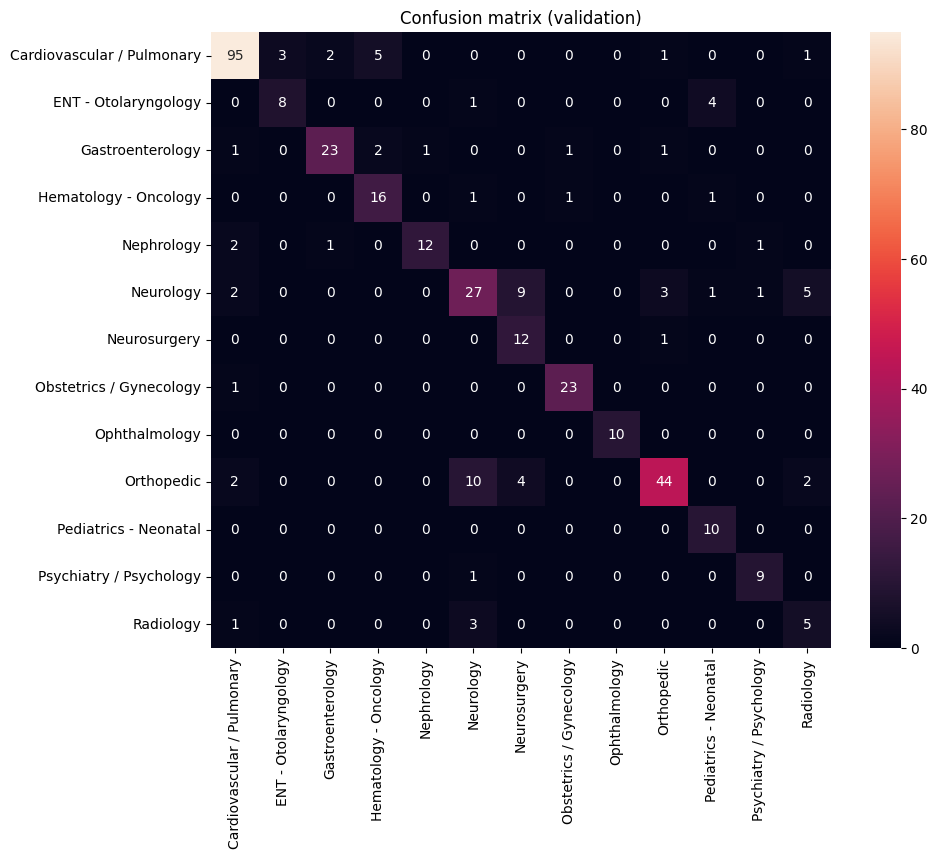

In [14]:
# Evaluate on validation set
y_val_pred = best_pipeline.predict(X_val)
print(classification_report(y_val, y_val_pred))
cm = confusion_matrix(y_val, y_val_pred, labels=best_pipeline.classes_)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=best_pipeline.classes_, yticklabels=best_pipeline.classes_)
plt.title('Confusion matrix (validation)')

In [15]:
# Final evaluation on test set
y_test_pred = best_pipeline.predict(X_test)
print('Test classification report:')
print(classification_report(y_test, y_test_pred))

# Predict on test data
y_test_pred = best_pipeline.predict(X_test)

# Full report
print(classification_report(y_test, y_test_pred))

# Accuracy as percentage
acc = accuracy_score(y_test, y_test_pred) * 100
print(f"Test Accuracy: {acc:.2f}%")

Test classification report:
                            precision    recall  f1-score   support

Cardiovascular / Pulmonary       0.95      0.90      0.92       109
      ENT - Otolaryngology       0.77      0.71      0.74        14
          Gastroenterology       0.95      0.88      0.91        41
     Hematology - Oncology       0.50      0.73      0.59        15
                Nephrology       0.88      0.70      0.78        10
                 Neurology       0.65      0.68      0.67        47
              Neurosurgery       0.52      0.85      0.64        20
   Obstetrics / Gynecology       0.96      0.75      0.84        32
             Ophthalmology       0.80      0.73      0.76        11
                Orthopedic       0.88      0.61      0.72        57
     Pediatrics - Neonatal       0.33      1.00      0.50         3
   Psychiatry / Psychology       0.80      0.89      0.84         9
                 Radiology       0.00      0.00      0.00         2

                  

In [27]:
# Save final pipeline artifact
os.makedirs('artifacts', exist_ok=True)
joblib.dump(best_pipeline, 'artifacts/model_pipeline.joblib')
print('Saved artifacts/model_pipeline.joblib')

Saved artifacts/model_pipeline.joblib


In [28]:
import joblib

# Load trained model
pipeline = joblib.load("artifacts/model_pipeline.joblib")

# Example input
sample_text = "changes in movement such as tremors, weakness, or coordination problems, and sensory issues like numbness or tingling"

# Predict
prediction = pipeline.predict([sample_text])
print("Predicted Specialty:", prediction[0])


Predicted Specialty: Neurology
